# Machine Learning - Homework 2: Part 1

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

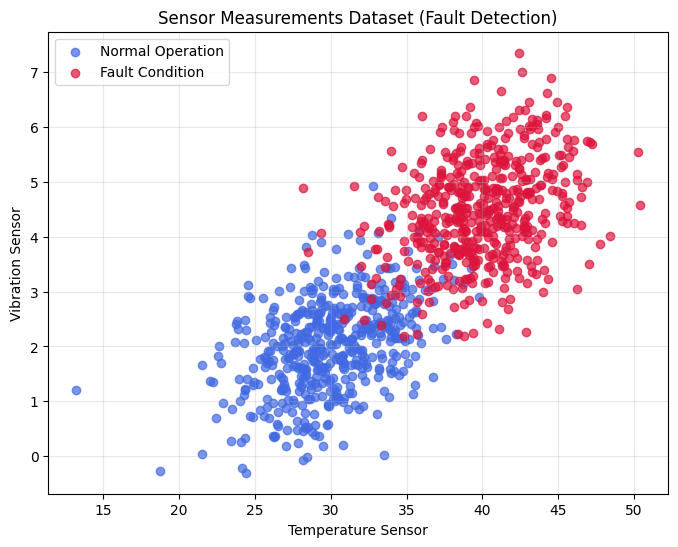

In [3]:
#############################
# DO NOT CHANGE THIS PART
#############################

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)

n_per_class = 500

# Normal machine operation
normal = np.random.multivariate_normal(
    mean=[30, 2],
    cov=[[12, 1.5],
         [1.5, 0.8]],
    size=n_per_class
)

# Fault condition
fault = np.random.multivariate_normal(
    mean=[40, 4.5],
    cov=[[12, 1.0],
         [1.0, 0.8]],
    size=n_per_class
)

X = np.vstack([normal, fault])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

#############################
# DO NOT CHANGE THIS PART
#############################


# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    normal[:,0], normal[:,1],
    color="royalblue",
    label="Normal Operation",
    alpha=0.7
)

plt.scatter(
    fault[:,0], fault[:,1],
    color="crimson",
    label="Fault Condition",
    alpha=0.7
)

plt.xlabel("Temperature Sensor")
plt.ylabel("Vibration Sensor")
plt.title("Sensor Measurements Dataset (Fault Detection)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#############################
# INITIAL SETUP (snapshot'a göre)
#############################

# Dataset boyutu
# Snapshot: m = 1000
m = X.shape[0]  # X'in satır sayısı zaten 1000 olmalı

# Random seed (dataset seed'i zaten dataset cell'inde kullanılıyor;
# burada sadece "initial setup" tablosunu takip etmek için bırakıyorum)
np.random.seed(55)

# Başlangıç ağırlıkları: w^(0) = [w0, w1, w2] = [0.0, 0.0, 0.0]
w = np.array([0.0, 0.0, 0.0])  # shape: (3,)

# Learning rate
eta = 0.1  # snapshot: η = 0.1

# Number of iterations
T = 10     # snapshot: T = 10


#############################
# Step 1 — Linear Score
# z = X_aug @ w
#############################

# Snapshot: X_aug in R^{m x 3} -> bias için önde 1'ler var
# X_aug = [1, x1, x2]
X_aug = np.column_stack([np.ones(m), X])  # shape: (m, 3)

# Linear score
# z_i = w0 + w1*x_{i,1} + w2*x_{i,2}
# (matris formu: z = X_aug w)
# Not: z'i her iterasyonda güncelleyeceğiz.


#############################
# Helper functions
#############################

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


#############################
# Step 3-5 — Loss + Gradient Descent (Full-batch GD)
#############################

loss_history = []

for t in range(T):
    # Step 2 — Sigmoid Activation
    z = X_aug @ w                      # shape: (m,)
    y_hat = sigmoid(z)                # ŷ_i = σ(z_i), shape: (m,)

    # Step 3 — Binary Cross-Entropy Loss
    # J(w) = -(1/m) * sum_i [ y_i log(ŷ_i) + (1-y_i) log(1-ŷ_i) ]
    eps = 1e-12  # log(0) engellemek için minimal sayısal güvenlik
    y_hat_clipped = np.clip(y_hat, eps, 1.0 - eps)
    J = -(1.0 / m) * np.sum(
        y * np.log(y_hat_clipped) + (1.0 - y) * np.log(1.0 - y_hat_clipped)
    )

    loss_history.append(J)

    # Step 4 — Gradient Computation
    # ∇_w J = (1/m) * X_aug^T @ (y_hat - y)
    grad = (1.0 / m) * (X_aug.T @ (y_hat - y))  # shape: (3,)

    # Step 5 — Gradient Descent Update (full-batch)
    w = w - eta * grad


#############################
# After training: Classification rule + error rate
#############################

# Predicted probabilities (son iterasyondan sonra z/y_hat yeniden hesaplıyoruz)
z = X_aug @ w
y_prob = sigmoid(z)

# Threshold: ŷ_i = 1 if σ(z_i) >= 0.5 else 0
y_pred = (y_prob >= 0.5).astype(int)

# Error Rate = (1/m) * sum_i 1[ŷ_i != y_i]
error_rate = np.mean(y_pred != y)

print("Final weights w = [w0, w1, w2]:", w)
print("Final loss J(w):", loss_history[-1])
print("Error rate:", error_rate)


#############################
# Decision Boundary (z = 0)
# w0 + w1*x1 + w2*x2 = 0  ->  x2 = -(w1/w2)*x1 - (w0/w2)
#############################

w0, w1, w2 = w
if abs(w2) > 1e-12:
    a = -(w1 / w2)  # x2 = a*x1 + b
    b = -(w0 / w2)
    print("Decision boundary: x2 = a*x1 + b with a =", a, ", b =", b)
else:
    print("Decision boundary: w2 ~ 0 olduğu için x2 line equation'ı stabil hesaplanamadı.")

# Machine Learning - Homework 2: Part 2

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

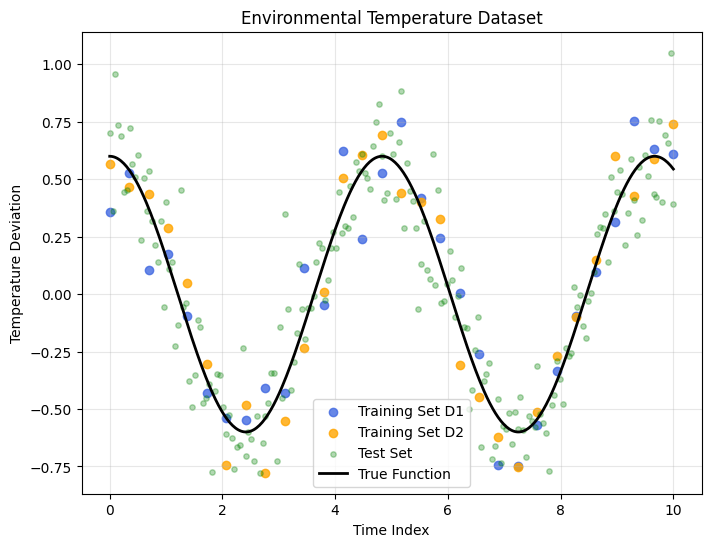

In [10]:
#############################
# DO NOT CHANGE THIS PART
#############################

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)

# Training dataset D1
x_train_d1 = np.linspace(0, 10, 30)
noise_d1 = np.random.normal(0, 0.15, size=x_train_d1.shape)
y_train_d1 = 0.6 * np.cos(1.3 * x_train_d1) + noise_d1


# Training dataset D2
x_train_d2 = np.linspace(0, 10, 30)
noise_d2 = np.random.normal(0, 0.15, size=x_train_d2.shape)
y_train_d2 = 0.6 * np.cos(1.3 * x_train_d2) + noise_d2


# Test dataset
x_test = np.linspace(0, 10, 200)
noise_test = np.random.normal(0, 0.15, size=x_test.shape)
y_test = 0.6 * np.cos(1.3 * x_test) + noise_test

#############################
# DO NOT CHANGE THIS PART
#############################


# True function (for visualization)
x_true = np.linspace(0, 10, 400)
y_true = 0.6 * np.cos(1.3 * x_true)


# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    x_train_d1, y_train_d1,
    color="royalblue",
    label="Training Set D1",
    alpha=0.8
)

plt.scatter(
    x_train_d2, y_train_d2,
    color="orange",
    label="Training Set D2",
    alpha=0.8
)

plt.scatter(
    x_test, y_test,
    color="green",
    label="Test Set",
    alpha=0.3,
    s=15
)

plt.plot(
    x_true, y_true,
    color="black",
    linewidth=2,
    label="True Function"
)

plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Environmental Temperature Dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.show()